In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
sns.set_theme(style="whitegrid")

In [55]:
df = pd.read_csv("sim_events_policy.csv")
df.head()

,timestamp,event_type,task_id,gpu_id,npts
0,2000,START,0,4,8727197
1,2000,START,4,4,7503288
2,2000,START,1,8,12550781
3,2000,START,23,8,7830895
4,2000,START,2,12,12542930


In [56]:
task_stats = df.groupby('task_id').agg(
    npts = ('npts','max'),
    start_time = ('timestamp','min'),
    finish_time = ('timestamp',lambda x: x[df.loc[x.index,'event_type']=='FINISH'].max()),
    interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
).dropna()
task_stats['duration'] = (task_stats['finish_time'] - task_stats['start_time']) / 1000.0


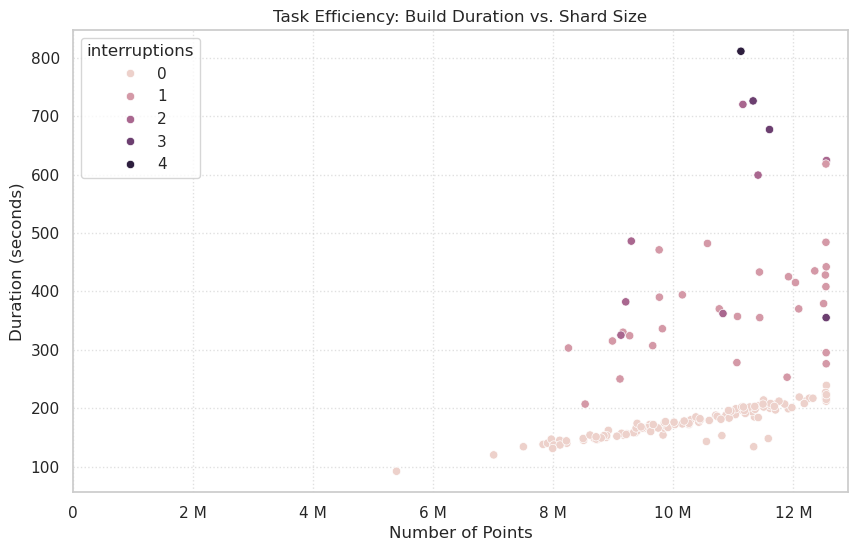

In [57]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=task_stats,x='npts',y='duration',hue='interruptions')
plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.xlim(left=0)
plt.title('Task Efficiency: Build Duration vs. Shard Size')
plt.xlabel('Number of Points')
plt.ylabel('Duration (seconds)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [58]:
df2 = pd.read_csv("sim_events_random.csv")
df2.head()

,timestamp,event_type,task_id,gpu_id,npts
0,2000,START,33,4,11896061
1,2000,START,80,4,8499342
2,2000,START,24,8,11916176
3,2000,START,36,8,8226717
4,2000,START,131,12,10931236


In [59]:
task_stats2 = df2.groupby('task_id').agg(
    npts = ('npts','max'),
    start_time = ('timestamp','min'),
    finish_time = ('timestamp',lambda x: x[df2.loc[x.index,'event_type']=='FINISH'].max()),
    interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
).dropna()
task_stats2['duration'] = (task_stats2['finish_time'] - task_stats2['start_time']) / 1000.0

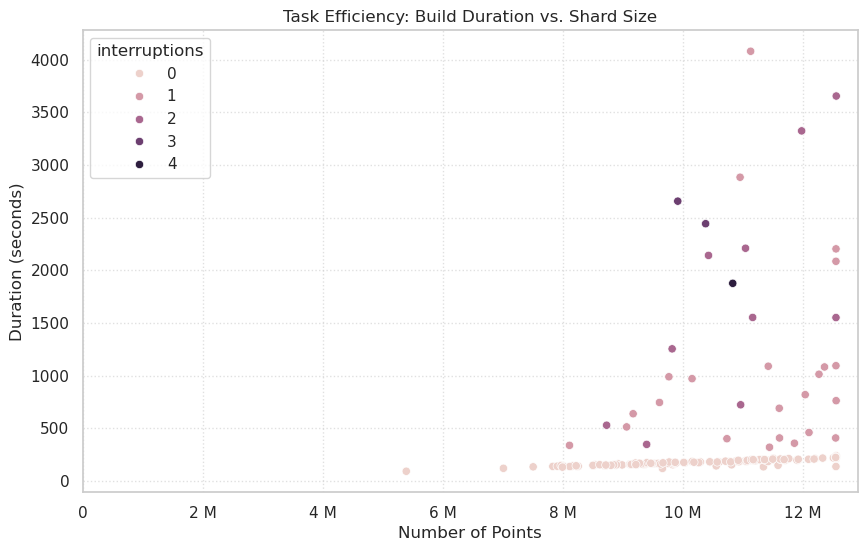

In [60]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=task_stats2,x='npts',y='duration',hue='interruptions')
plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.xlim(left=0)
plt.title('Task Efficiency: Build Duration vs. Shard Size')
plt.xlabel('Number of Points')
plt.ylabel('Duration (seconds)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [49]:
starts = df[df['event_type'] == 'START'][['timestamp']].copy()
starts['change'] = 1
ends = df[df['event_type'].isin(['FINISH', 'INTERRUPT'])][['timestamp']].copy()
ends['change'] = -1
concurrency = pd.concat([starts, ends]).sort_values('timestamp')
concurrency['active_tasks'] = concurrency['change'].cumsum()

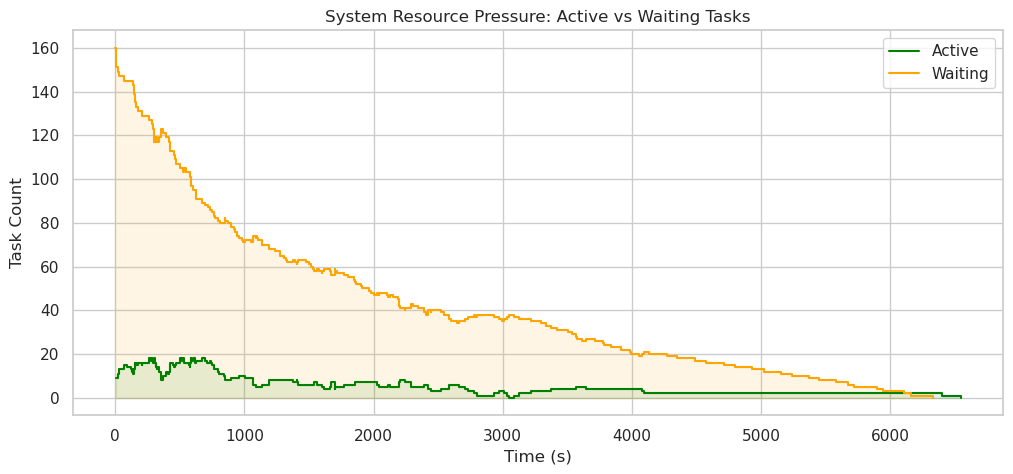

In [50]:
# Robust System Resource Pressure (Active vs Waiting)
def get_timeline_v2(df_in, start_types, end_types, init_count=0):
    starts = df_in[df_in['event_type'].isin(start_types)][['timestamp']].copy()
    starts['change'] = 1
    ends = df_in[df_in['event_type'].isin(end_types)][['timestamp']].copy()
    ends['change'] = -1
    tl = pd.concat([starts, ends]).sort_values('timestamp')
    tl = tl.groupby('timestamp')['change'].sum().reset_index()
    if init_count > 0:
        tl = pd.concat([pd.DataFrame([{'timestamp': 0, 'change': init_count}]), tl])
    tl['count'] = tl['change'].cumsum()
    return tl

active_tasks = get_timeline_v2(df, ['START'], ['FINISH', 'INTERRUPT'])
waiting_tasks = get_timeline_v2(df, ['INTERRUPT'], ['START'])
# Assume all tasks are waiting at t=0 until their first START
initial_total = len(df['task_id'].unique())
waiting_tasks = pd.concat([pd.DataFrame([{'timestamp': 0, 'change': initial_total}]), waiting_tasks]).sort_values('timestamp')
waiting_tasks['count'] = waiting_tasks['change'].cumsum().clip(lower=0)

plt.figure(figsize=(12, 5))
plt.step(active_tasks['timestamp']/1000, active_tasks['count'], label='Active', color='green', where='post')
plt.step(waiting_tasks['timestamp']/1000, waiting_tasks['count'], label='Waiting', color='orange', where='post')
plt.fill_between(active_tasks['timestamp']/1000, active_tasks['count'], alpha=0.1, color='green', step='post')
plt.fill_between(waiting_tasks['timestamp']/1000, waiting_tasks['count'], alpha=0.1, color='orange', step='post')
plt.title('System Resource Pressure: Active vs Waiting Tasks')
plt.xlabel('Time (s)'); plt.ylabel('Task Count'); plt.legend(); plt.show()

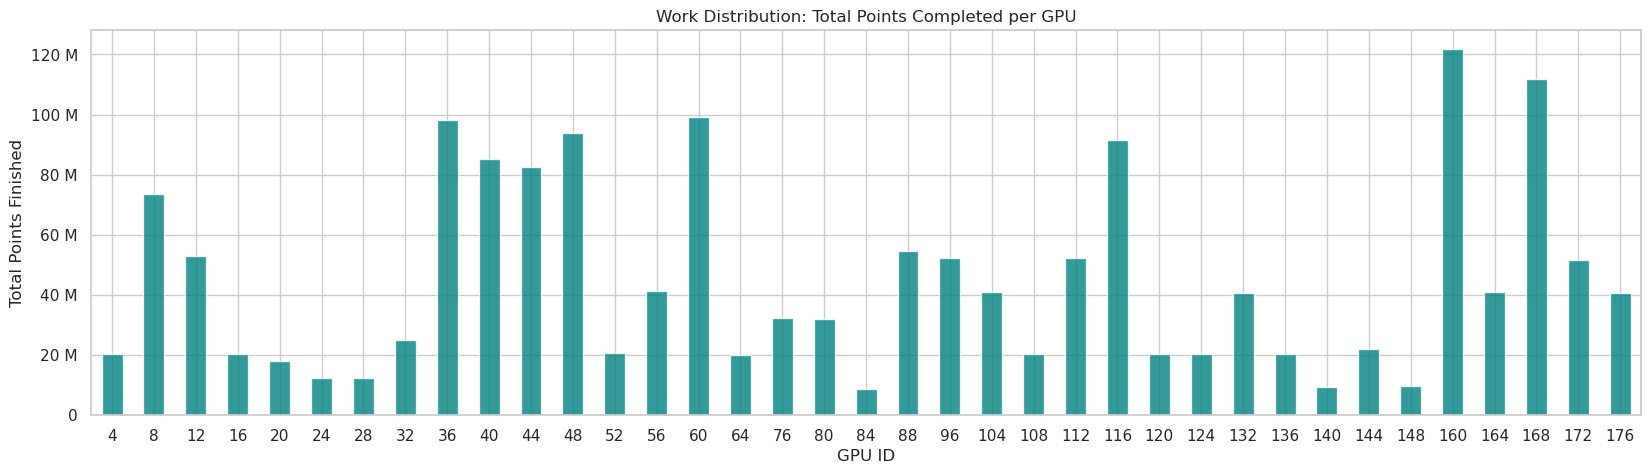

In [25]:
gpu_work = df[df['event_type'] == 'FINISH'].groupby('gpu_id')['npts'].sum().sort_index()
plt.figure(figsize=(20,5))
gpu_work.plot(kind='bar',color='teal',alpha=0.8)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Work Distribution: Total Points Completed per GPU')
plt.xlabel('GPU ID')
plt.ylabel('Total Points Finished')
plt.xticks(rotation=0)
plt.show()

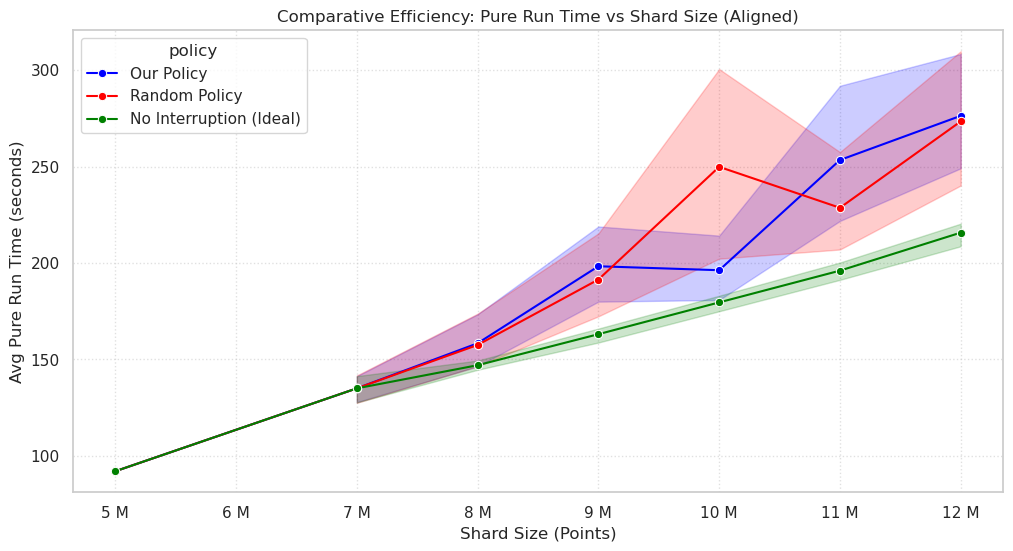

In [62]:
def get_true_pure_run_metrics(filename, label, delay_ms=0):
    df = pd.read_csv(filename)
    finished = df[df['event_type'] == 'FINISH']['task_id'].unique()
    df = df[df['task_id'].isin(finished)].sort_values(['task_id', 'timestamp'])
    df['timestamp'] = (df['timestamp'] - delay_ms).clip(lower=0)
    df['diff'] = df.groupby('task_id')['timestamp'].diff()
    df['prev_type'] = df.groupby('task_id')['event_type'].shift(1)
    run_mask = (df['prev_type'] == 'START') & df['event_type'].isin(['FINISH', 'INTERRUPT'])
    stats = df[run_mask].groupby('task_id').agg({'diff': 'sum', 'npts': 'max'}).reset_index()
    stats['pure_run_s'] = stats['diff'] / 1000.0
    stats['npts_bin'] = (stats['npts'] // 1_000_000) * 1_000_000
    return stats[['npts_bin', 'pure_run_s']].assign(policy=label)

df_all = pd.concat([
    get_true_pure_run_metrics("sim_events_policy.csv", "Our Policy (Retry-Only)", delay_ms=2000),
    get_true_pure_run_metrics("sim_events_random.csv", "Random Policy", delay_ms=2000),
    get_true_pure_run_metrics("sim_events_nopreempt.csv", "No Interruption (Ideal)", delay_ms=0)
])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x='npts_bin', y='pure_run_s', hue='policy', 
             marker='o', palette={'Our Policy (Retry-Only)': 'blue', 'Random Policy': 'red', 'No Interruption (Ideal)': 'green'})

plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.title("Comparative Efficiency: Pure Run Time (Retry-Only Policy)")
plt.xlabel("Shard Size (Points)"); plt.ylabel("Avg Pure Run Time (seconds)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [63]:
def get_wait_breakdown(filename, label, delay_ms=2000):
    df_raw = pd.read_csv(filename)
    df_raw['timestamp'] = (df_raw['timestamp'] - delay_ms).clip(lower=0)
    finished_ids = df_raw[df_raw['event_type'] == 'FINISH']['task_id'].unique()
    
    stats = []
    for tid in finished_ids:
        task_events = df_raw[df_raw['task_id'] == tid].sort_values('timestamp')
        first_start = task_events[task_events['event_type'] == 'START']['timestamp'].min()
        
        # Pure Run Time
        task_events['diff'] = task_events['timestamp'].diff()
        task_events['prev_type'] = task_events['event_type'].shift(1)
        run_mask = (task_events['prev_type'] == 'START') & task_events['event_type'].isin(['FINISH', 'INTERRUPT'])
        pure_run_s = task_events[run_mask]['diff'].sum() / 1000.0
        
        last_finish_s = task_events['timestamp'].max() / 1000.0
        total_wait_s = last_finish_s - pure_run_s
        
        stats.append({
            'task_id': tid,
            'initial_wait_s': first_start / 1000.0,
            'resched_wait_s': total_wait_s - (first_start / 1000.0),
            'interrupts': (task_events['event_type'] == 'INTERRUPT').sum()
        })
    return pd.DataFrame(stats).assign(policy=label)

breakdown = pd.concat([
    get_wait_breakdown('sim_events_policy.csv', 'Smallest-First'),
    get_wait_breakdown('sim_events_random.csv', 'Random')
])

summary = breakdown.groupby('policy').agg({
    'initial_wait_s': 'mean',
    'resched_wait_s': 'mean',
    'interrupts': 'max'
}).rename(columns={'initial_wait_s': 'Avg Initial Wait (s)', 
                   'resched_wait_s': 'Avg Resched Wait (s)',
                   'interrupts': 'Max Interrupts'})

print("Comparison of Wait Time Dynamics:")
display(summary)

Comparison of Wait Time Dynamics:


,Avg Initial Wait (s),Avg Resched Wait (s),Max Interrupts
policy,,,
Random,1241.7625,222.94375,4
Smallest-First,1421.5375,22.14375,4


In [64]:
def get_forensic_data(filename, delay_ms=2000):
    df_raw = pd.read_csv(filename)
    df_raw['timestamp_s'] = (df_raw['timestamp'] - delay_ms) / 1000.0
    starts = df_raw[df_raw['event_type'] == 'START'].copy()
    
    plt.figure(figsize=(15, 8))
    plt.scatter(starts['timestamp_s'], starts['npts'], alpha=0.3, s=10, label='Task Start Events')
    interrupts = df_raw[df_raw['event_type'] == 'INTERRUPT'].copy()
    if not interrupts.empty:
        ax2 = plt.gca().twinx()
        sns.kdeplot(interrupts['timestamp_s'], ax=ax2, color='red', bw_adjust=0.5, fill=True, alpha=0.2, label='Preemption Storm Intensity')
        ax2.set_ylabel("Preemption Density (Storm Intensity)", color='red')
        ax2.set_ylim(0)

    plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
    plt.title("Forensic Timeline: When Shard Sizes met the Preemption Storms")
    plt.xlabel("Simulation Time (seconds)")
    plt.ylabel("Shard Size (Points)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

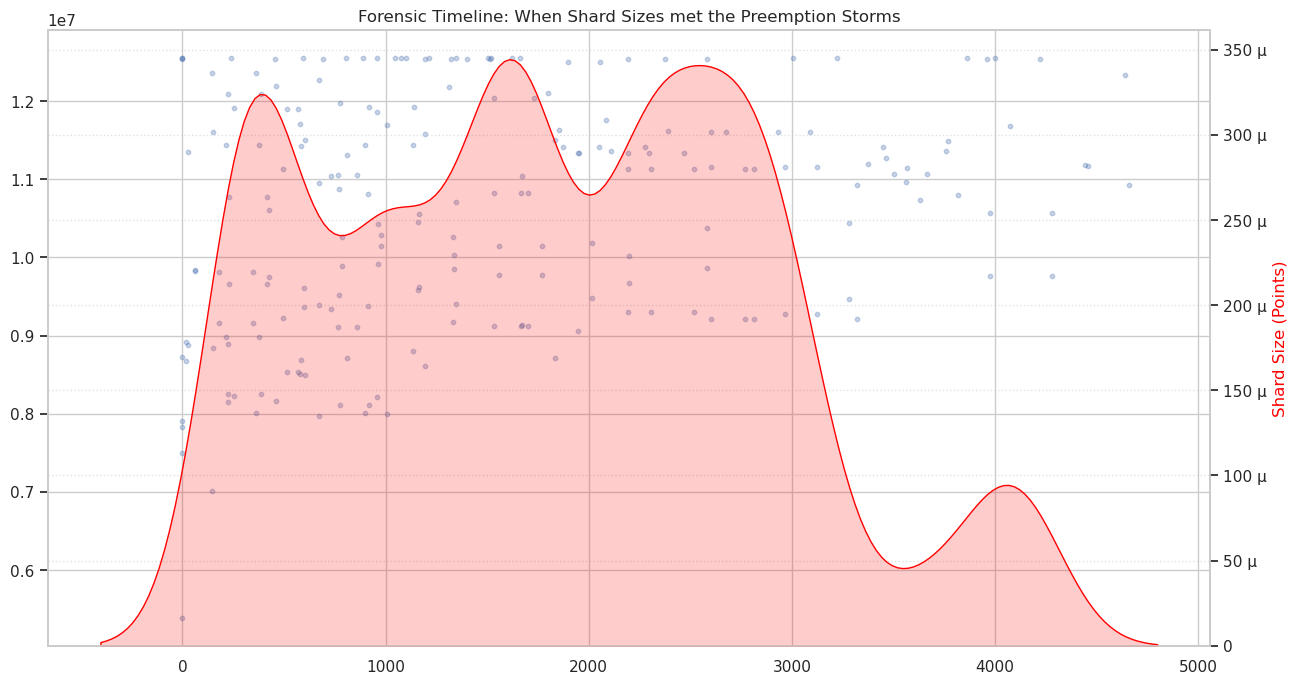

In [65]:
get_forensic_data('sim_events_policy.csv')